# Linear Regression: Visualizing Contour Plots

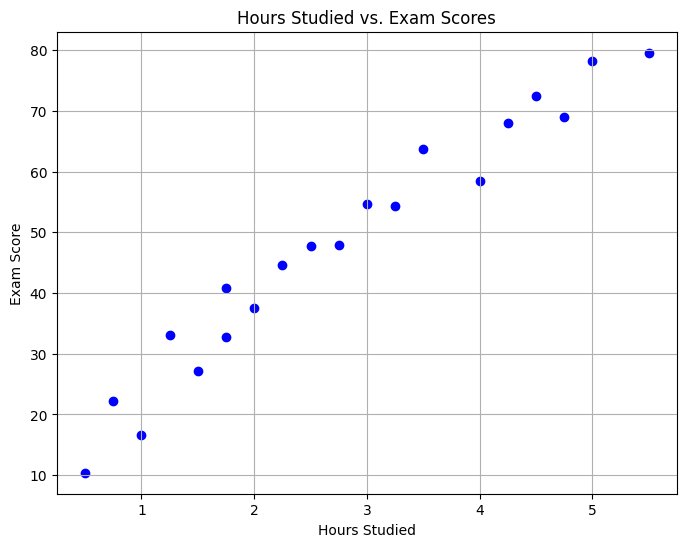

In [ ]:
# Data setup and visualization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data: hours studied vs. exam scores
hours_studied = np.array([[0.5], [0.75], [1.], [1.25], [1.5], [1.75], [1.75], [2.], [2.25], [2.5], [2.75], [3.], [3.25], [3.5], [4.], [4.25], [4.5], [4.75], [5.], [5.5]])
exam_scores = np.array([10.4, 22.2, 16.6, 33.1, 27.2, 32.8, 40.8, 37.5, 44.7, 47.7, 47.9, 54.7, 54.3, 63.8, 58.4, 68.1, 72.4, 69., 78.2, 79.6])

# Plotting the data
plt.figure(figsize=(8, 6))
plt.scatter(hours_studied, exam_scores, color='blue')

plt.title('Hours Studied vs. Exam Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()


In [ ]:
# Fitting the linear regression model
model = LinearRegression()
model.fit(hours_studied, exam_scores)

beta0_star = model.intercept_
beta1_star = model.coef_[0]

beta0_star, beta1_star


(11.097900224458783, 13.227659112301783)

In [ ]:
model.score(hours_studied, exam_scores) # R square

0.9537952336323572

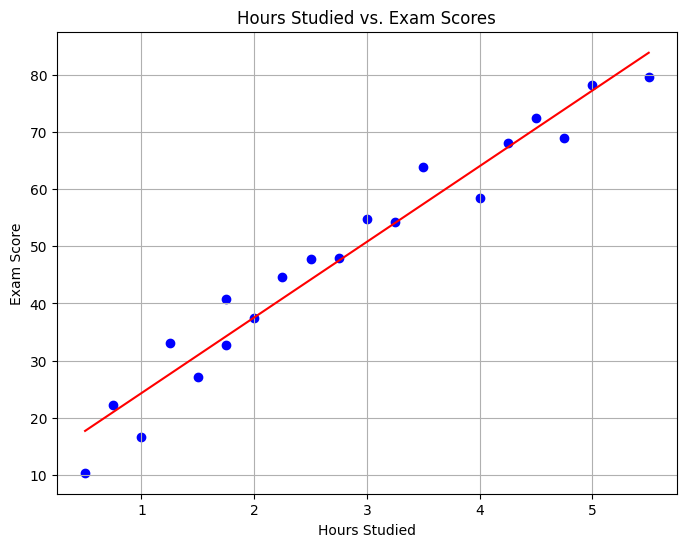

In [ ]:
#
y_prediction = model.predict(hours_studied)

# Plotting the data
plt.figure(figsize=(8, 6))
plt.scatter(hours_studied, exam_scores, color='blue')
plt.plot(hours_studied, y_prediction, color='red')

plt.title('Hours Studied vs. Exam Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()


In [ ]:
# Defining the cost functions

def compute_mse(beta0, beta1, X, y, model):
    model.intercept_ = beta0
    model.coef_ = np.array([beta1])
    predictions = model.predict(X)
    m = len(y)
    return 1 / m * np.sum((predictions - y) ** 2)

def compute_mae(beta0, beta1, X, y, model):
    model.intercept_ = beta0
    model.coef_ = np.array([beta1])
    predictions = model.predict(X)
    m = len(y)
    return 1 / m * np.sum(np.abs(predictions - y))

def compute_huber(beta0, beta1, X, y, model, delta=1.0):
    model.intercept_ = beta0
    model.coef_ = np.array([beta1])
    predictions = model.predict(X)
    abs_diff = np.abs(predictions - y)
    m = len(y)
    return 1 / m * np.sum(np.where(abs_diff <= delta, 0.5 * abs_diff ** 2, delta * abs_diff - 0.5 * delta ** 2))

def compute_logcosh(beta0, beta1, X, y, model):
    model.intercept_ = beta0
    model.coef_ = np.array([beta1])
    predictions = model.predict(X)
    m = len(y)
    return 1 / m * np.sum(np.log(np.cosh(predictions - y)))


# Setting up the grid around the optimal values
beta0_values_centered = np.linspace(beta0_star - 7, beta0_star + 7, 51)
beta1_values_centered = np.linspace(beta1_star - 4, beta1_star + 4, 51)

# Computing the cost values for each cost function over the grid
J_values_mse = np.zeros((len(beta0_values_centered), len(beta1_values_centered)))
J_values_mae = np.zeros_like(J_values_mse)
J_values_huber = np.zeros_like(J_values_mse)
J_values_logcosh = np.zeros_like(J_values_mse)

for i, beta0 in enumerate(beta0_values_centered):
    for j, beta1 in enumerate(beta1_values_centered):
        J_values_mse[i, j] = compute_mse(beta0, beta1, hours_studied, exam_scores, model)
        J_values_mae[i, j] = compute_mae(beta0, beta1, hours_studied, exam_scores, model)
        J_values_huber[i, j] = compute_huber(beta0, beta1, hours_studied, exam_scores, model)
        J_values_logcosh[i, j] = compute_logcosh(beta0, beta1, hours_studied, exam_scores, model)

# Checking the first few values for MSE as a sample
J_values_mse[:5, :5]


array([[382.2412241, 363.5433841, 345.3538641, 327.6726641, 310.4997841],
       [372.1556241, 353.7075441, 335.7677841, 318.3363441, 301.4132241],
       [362.2268241, 344.0285041, 326.3385041, 309.1568241, 292.4834641],
       [352.4548241, 334.5062641, 317.0660241, 300.1341041, 283.7105041],
       [342.8396241, 325.1408241, 307.9503441, 291.2681841, 275.0943441]])

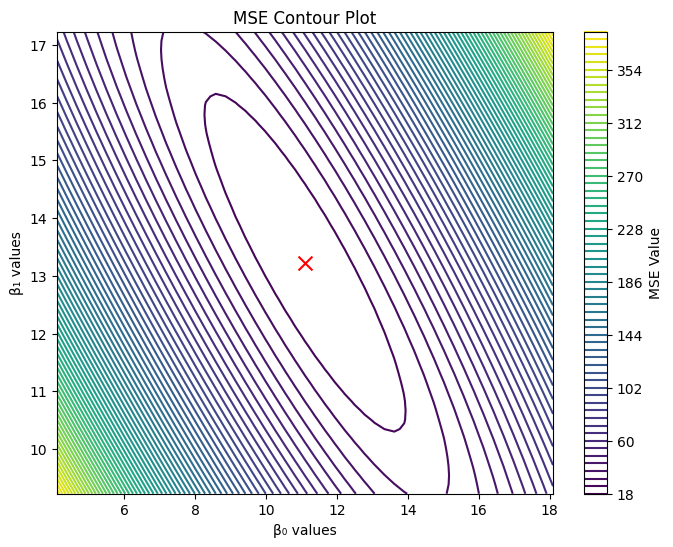

In [ ]:
# MSE
plt.figure(figsize=(8, 6))

contour_plot = plt.contour(beta0_values_centered, beta1_values_centered, J_values_mse, levels=60, cmap="viridis")
plt.colorbar(contour_plot, label='MSE Value')


plt.scatter(beta0_star, beta1_star, color='red', marker='x', s=100)

plt.title('MSE Contour Plot')
plt.xlabel('β₀ values')
plt.ylabel('β₁ values')


plt.show()

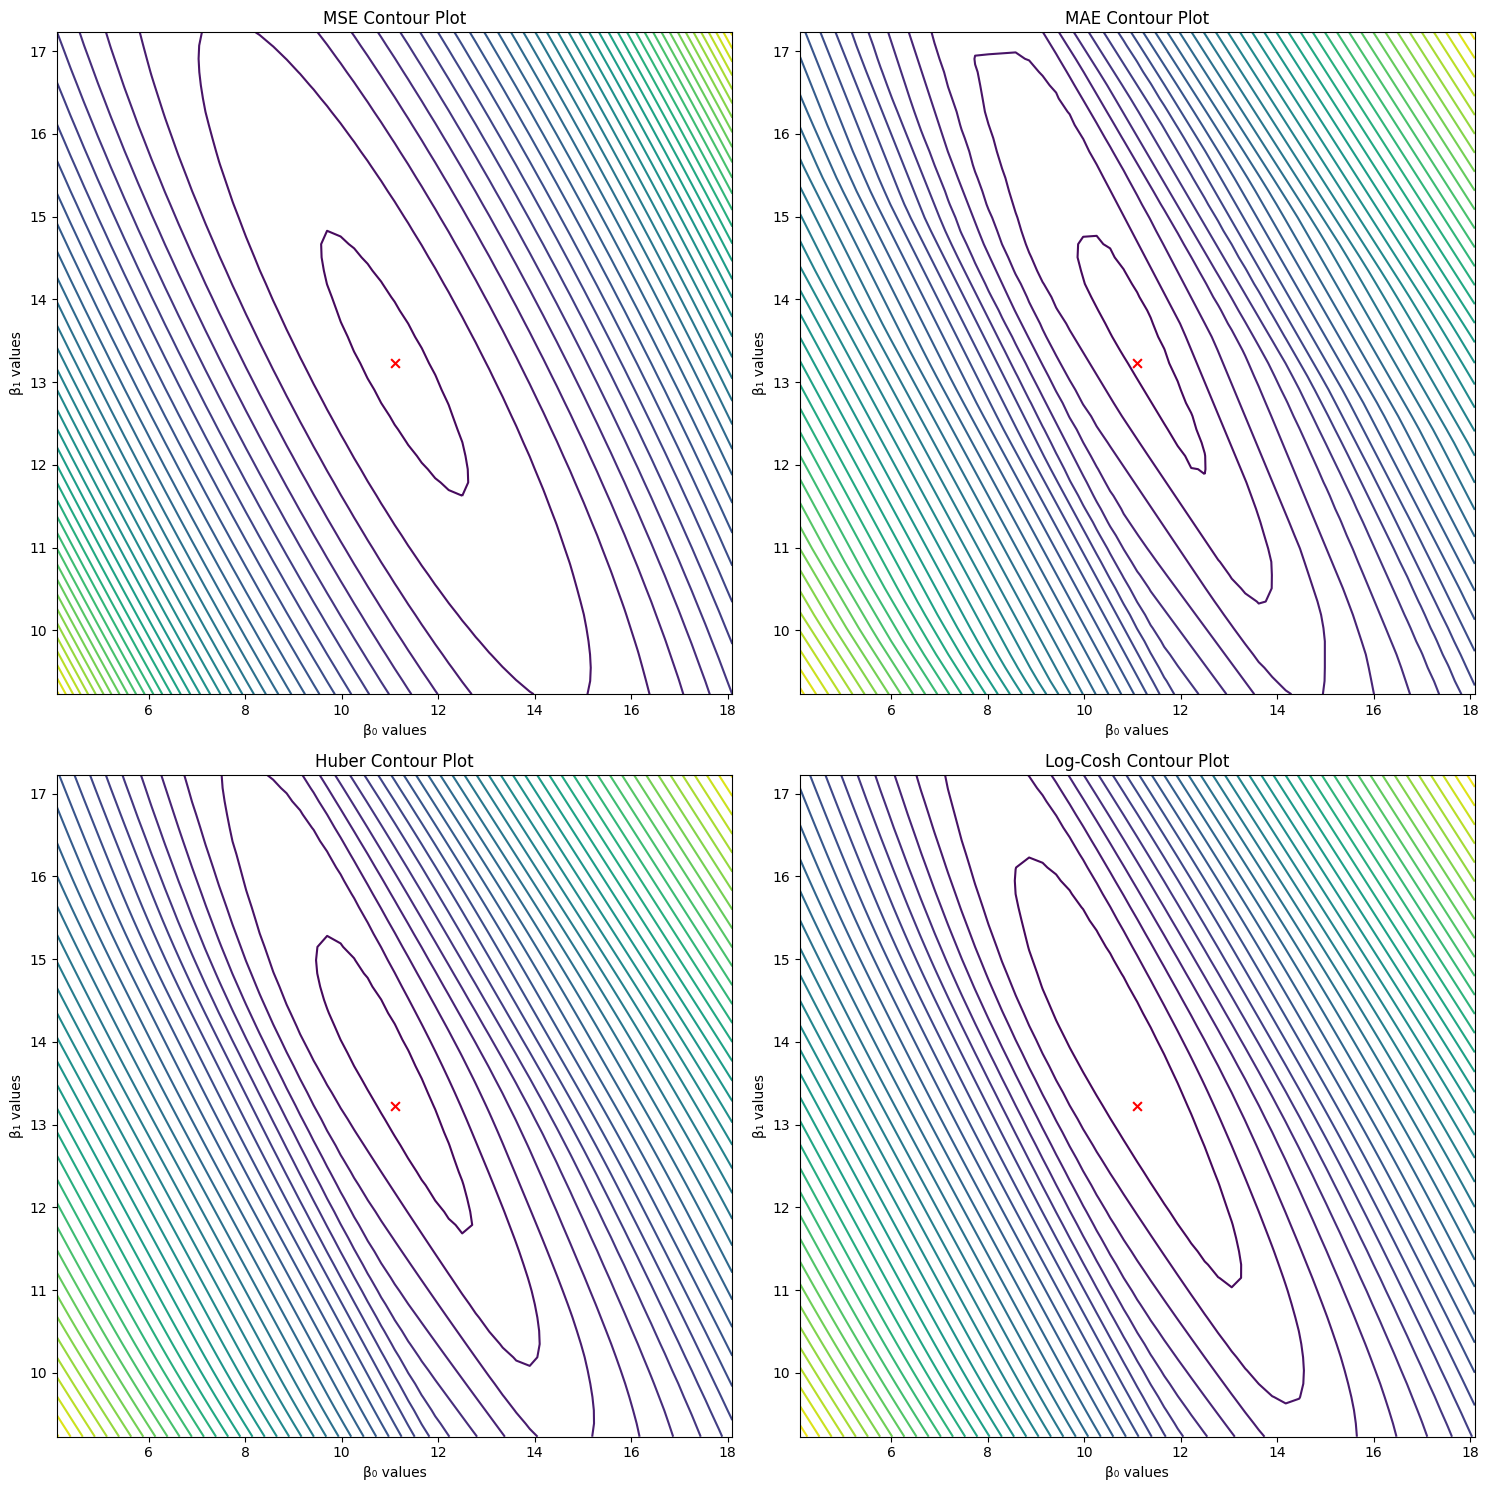

In [ ]:
# Plotting contour plots for each cost function

fig, axs = plt.subplots(2, 2, figsize=(15, 15))

n_line = 40
# MSE
cp_mse = axs[0, 0].contour(beta0_values_centered, beta1_values_centered, J_values_mse, levels=n_line, cmap="viridis")
axs[0, 0].scatter(beta0_star, beta1_star, color='red', marker='x', s=n_line)
axs[0, 0].set_title('MSE Contour Plot')
axs[0, 0].set_xlabel('β₀ values')
axs[0, 0].set_ylabel('β₁ values')

# MAE
cp_mae = axs[0, 1].contour(beta0_values_centered, beta1_values_centered, J_values_mae, levels=n_line, cmap="viridis")
axs[0, 1].scatter(beta0_star, beta1_star, color='red', marker='x', s=n_line)
axs[0, 1].set_title('MAE Contour Plot')
axs[0, 1].set_xlabel('β₀ values')
axs[0, 1].set_ylabel('β₁ values')

# Huber
cp_huber = axs[1, 0].contour(beta0_values_centered, beta1_values_centered, J_values_huber, levels=n_line, cmap="viridis")
axs[1, 0].scatter(beta0_star, beta1_star, color='red', marker='x', s=n_line)
axs[1, 0].set_title('Huber Contour Plot')
axs[1, 0].set_xlabel('β₀ values')
axs[1, 0].set_ylabel('β₁ values')

# Log-Cosh
cp_logcosh = axs[1, 1].contour(beta0_values_centered, beta1_values_centered, J_values_logcosh, levels=n_line, cmap="viridis")
axs[1, 1].scatter(beta0_star, beta1_star, color='red', marker='x', s=n_line)
axs[1, 1].set_title('Log-Cosh Contour Plot')
axs[1, 1].set_xlabel('β₀ values')
axs[1, 1].set_ylabel('β₁ values')





plt.tight_layout()
plt.show()


In [ ]:
#! pip install statsmodels

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import random


# Load the California Housing dataset
california = fetch_california_housing()


In [ ]:
type(california)

sklearn.utils._bunch.Bunch

In [ ]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [ ]:
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [ ]:
california_df = pd.DataFrame(california.data, columns=california.feature_names)
california_df['MedHouseVal'] = california.target

# Splitting the data into train and test
X_california = california_df.drop("MedHouseVal", axis=1)
y_california = california_df["MedHouseVal"]
X_train_california, X_test_california, y_train_california, y_test_california = train_test_split(X_california, y_california, test_size=0.2, random_state=42)

# Train a linear regression model
lr_california = LinearRegression()
lr_california.fit(X_train_california, y_train_california)

# Evaluate the model on the test set
y_pred_california = lr_california.predict(X_test_california)

# Statistical analysis of the model using statsmodels
X_train_california_with_const = sm.add_constant(X_train_california)  # Adding a constant for the intercept
model_california = sm.OLS(y_train_california, X_train_california_with_const).fit()
summary_california = model_california.summary()

summary_california


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     3261.
Date:                Tue, 15 Aug 2023   Prob (F-statistic):               0.00
Time:                        13:53:09   Log-Likelihood:                -17998.
No. Observations:               16512   AIC:                         3.601e+04
Df Residuals:                   16503   BIC:                         3.608e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0233      0.728    -50.835      0.000     -38.451     -35.596
MedInc         0.4487      0.005     95.697      0.000       0.439       0.458
HouseAge       0.0097      0.000     19.665      0.000       0.009       0.011
AveRooms      -0.1233      0.007    -18.677      0.000      -0.136      -0.110
AveBedrms      0.7831      0.033     23.556      0.000       0.718       0.848
Population  -2.03e-06   5.25e-06     -0.387      0.699   -1.23e-05    8.26e-06
AveOccup      -0.0035      0.000     -7.253      0.000      -0.004      -0.003
Latitude      -0.4198      0.008    -52.767      0.000      -0.435      -0.404
Longitude     -0.4337      0.008    -52.117      0.000      -0.450      -0.417
==============================================================================
Omnibus:                     3333.187   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9371.466
Skew:                           1.071   Prob(JB):                         0.00
Kurtosis:                       6.006   Cond. No.                     2.38e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.38e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Top Section:
Dep. Variable: The dependent variable (or the target variable) for which the regression model is built.

Model: The type of model used, in this case, OLS.

Method: The method used to estimate the parameters; "Least Squares" means the coefficients are determined by minimizing the sum of squares of the residuals.

No. Observations: Total number of data points (or rows) used in the model.

DF Residuals: Degrees of freedom of the residuals, calculated as the number of observations minus the number of parameters.

DF Model: Degrees of freedom of the model, equivalent to the number of predictors.


R-squared: Proportion of the variance in the dependent variable that is predictable from the independent variables. Ranges from 0 to 1.

Adj. R-squared: Adjusted R-squared considers the number of predictors in the model. It only increases if a new predictor enhances the model more than expected by chance. It can be negative if the model is overfitted.
  
    
Coefficients Table:

coef: The estimated coefficient. Represents the change in the target variable for a one-unit change in the predictor, holding all other predictors constant.

std err: Standard error of the coefficient estimate. It's a measure of the variability in the estimate.

t: t-statistic. The coefficient divided by its standard error. It's a measure of how many standard deviations away our coefficient estimate is from 0.

P>|t|: P-value of the t-statistic. A low value (typically < 0.05) indicates that the predictor is a significant predictor of the target variable.
    

   
In practical terms, you would:

Look at the R-squared and Adjusted R-squared values to understand the goodness of fit.

Look at the P-value for each predictor to check its significance.

The coefficients tell you about the relationship and its direction (positive/negative) between each predictor and the target variable.
    

In [ ]:
california_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:


# Generate a random integer between 1 and 100 (inclusive)
random_numbers = [random.randint(0, len(california.data)-1 ) for _ in range(1000)]


In [ ]:
california_df = pd.DataFrame(california.data[random_numbers,:],  columns=california.feature_names)
california_df['MedHouseVal'] = california.target[random_numbers]



# Splitting the data into train and test
X_california = california_df.drop("MedHouseVal", axis=1)
y_california = california_df["MedHouseVal"]
X_train_california, X_test_california, y_train_california, y_test_california = train_test_split(X_california, y_california, test_size=0.2, random_state=42)

# Train a linear regression model
lr_california = LinearRegression()
lr_california.fit(X_train_california, y_train_california)

# Evaluate the model on the test set
y_pred_california = lr_california.predict(X_test_california)

# Statistical analysis of the model using statsmodels
X_train_california_with_const = sm.add_constant(X_train_california)  # Adding a constant for the intercept
model_california = sm.OLS(y_train_california, X_train_california_with_const).fit()
summary_california = model_california.summary()

summary_california


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            MedHouseVal   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     220.9
Date:                Tue, 15 Aug 2023   Prob (F-statistic):          8.96e-196
Time:                        13:53:19   Log-Likelihood:                -813.46
No. Observations:                 800   AIC:                             1645.
Df Residuals:                     791   BIC:                             1687.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -31.5109      2.992    -10.533      0.000     -37.383     -25.638
MedInc         0.4533      0.020     22.165      0.000       0.413       0.493
HouseAge       0.0093      0.002      4.189      0.000       0.005       0.014
AveRooms      -0.0916      0.030     -3.062      0.002      -0.150      -0.033
AveBedrms      0.6515      0.156      4.186      0.000       0.346       0.957
Population  4.118e-05   2.75e-05      1.499      0.134   -1.27e-05    9.51e-05
AveOccup      -0.3012      0.031     -9.787      0.000      -0.362      -0.241
Latitude      -0.4021      0.032    -12.717      0.000      -0.464      -0.340
Longitude     -0.3890      0.034    -11.544      0.000      -0.455      -0.323
==============================================================================
Omnibus:                      148.955   Durbin-Watson:                   2.069
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              321.262
Skew:                           1.029   Prob(JB):                     1.73e-70
Kurtosis:                       5.324   Cond. No.                     2.14e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.14e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""